In [ ]:
# Cell 1 — Load isochrones + SDSS field CSVs (target + controls), and build "error-bar overlap" candidates

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# -----------------------------
# CONFIG
# -----------------------------
ISO_DIR = "isochrones"             # folder used by your dartmouth loader
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")   # includes sdss_target.csv too

# Sgr reference distance (for shifting isochrones to apparent mags)
d_pc = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)

# quality cuts (keep light; you can tighten later)
ERR_MAX = 0.15
G0_MAX  = 23.5
R0_MAX  = 23.5

# overlap tolerance (to avoid being hypersensitive to tiny numerical gaps)
# Think of this as "additional model/isochrone thickness" in magnitudes
ISO_PAD = 0.02

# -----------------------------
# 1) Load Dartmouth isochrones
# -----------------------------
from isochrones.dartmouth_iso import load_isochrones
isos = load_isochrones(ISO_DIR)

iso5  = isos["5gyr"]
iso13 = isos["13gyr"]

def iso_to_apparent_arrays(iso, DM):
    """Return arrays for an isochrone shifted to apparent mags at DM."""
    df_iso = iso.df
    g_app = (df_iso["sdss_g"].to_numpy()) + DM
    r_app = (df_iso["sdss_r"].to_numpy()) + DM
    c_app = g_app - r_app
    return c_app, g_app

c5_iso,  g5_iso  = iso_to_apparent_arrays(iso5,  DM_SGR)
c13_iso, g13_iso = iso_to_apparent_arrays(iso13, DM_SGR)

# -----------------------------
# 2) Load SDSS field CSVs and compute dereddened mags + errors
# -----------------------------
def load_sdss_field(path):
    df = pd.read_csv(path, comment="#")

    # dereddened mags/colors
    df["g0"]  = df["psfMag_g"] - df["extinction_g"]
    df["r0"]  = df["psfMag_r"] - df["extinction_r"]
    df["g_r"] = df["g0"] - df["r0"]

    # photometric errors (assume columns exist)
    df["sig_g"]  = df["psfMagErr_g"]
    df["sig_r"]  = df["psfMagErr_r"]
    df["sig_gr"] = np.sqrt(df["sig_g"]**2 + df["sig_r"]**2)

    # light quality mask
    m = (
        (df["sig_g"] < ERR_MAX) &
        (df["sig_r"] < ERR_MAX) &
        (df["g0"] < G0_MAX) &
        (df["r0"] < R0_MAX)
    )
    return df[m].copy()

paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = []
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    fields.append((fid, load_sdss_field(p)))

field_map = {fid: df for fid, df in fields}
print(f"Loaded {len(fields)} fields. Target present? {'target' in field_map}")

# -----------------------------
# 3) Candidate definition: error bars overlap isochrone (rectangle overlap)
# -----------------------------
def candidates_by_errorbar_overlap(df, c_iso, g_iso, iso_pad=0.0):
    """
    A star is a candidate if there exists at least one isochrone point (c_i, g_i)
    that lies within the star's (color,mag) error rectangle:
        |c_i - c_star| <= sig_color + iso_pad
        |g_i - g_star| <= sig_g + iso_pad

    Returns boolean mask of length len(df).
    """
    c_star = df["g_r"].to_numpy()
    g_star = df["g0"].to_numpy()
    sc     = df["sig_gr"].to_numpy()
    sg     = df["sig_g"].to_numpy()

    cand = np.zeros(len(df), dtype=bool)

    # Vectorized per-star scan (fast enough for a few thousand stars x a few thousand iso points)
    # We do a two-stage gate: first mag window, then color window.
    for j in range(len(df)):
        m_mag = np.abs(g_iso - g_star[j]) <= (sg[j] + iso_pad)
        if not np.any(m_mag):
            continue
        # only check colors for mag-compatible iso points
        if np.any(np.abs(c_iso[m_mag] - c_star[j]) <= (sc[j] + iso_pad)):
            cand[j] = True
    return cand

# compute candidate masks for target + all controls, for both isochrones
for fid, df in fields:
    df["cand_5_overlap"]  = candidates_by_errorbar_overlap(df, c5_iso,  g5_iso,  iso_pad=ISO_PAD)
    df["cand_13_overlap"] = candidates_by_errorbar_overlap(df, c13_iso, g13_iso, iso_pad=ISO_PAD)
    df["cand_either_overlap"] = df["cand_5_overlap"] | df["cand_13_overlap"]

print("Example (target):",
      field_map["target"]["cand_either_overlap"].sum(),
      "candidates out of",
      len(field_map["target"]))

Loaded 31 fields. Target present? True
Example (target): 880 candidates out of 3206


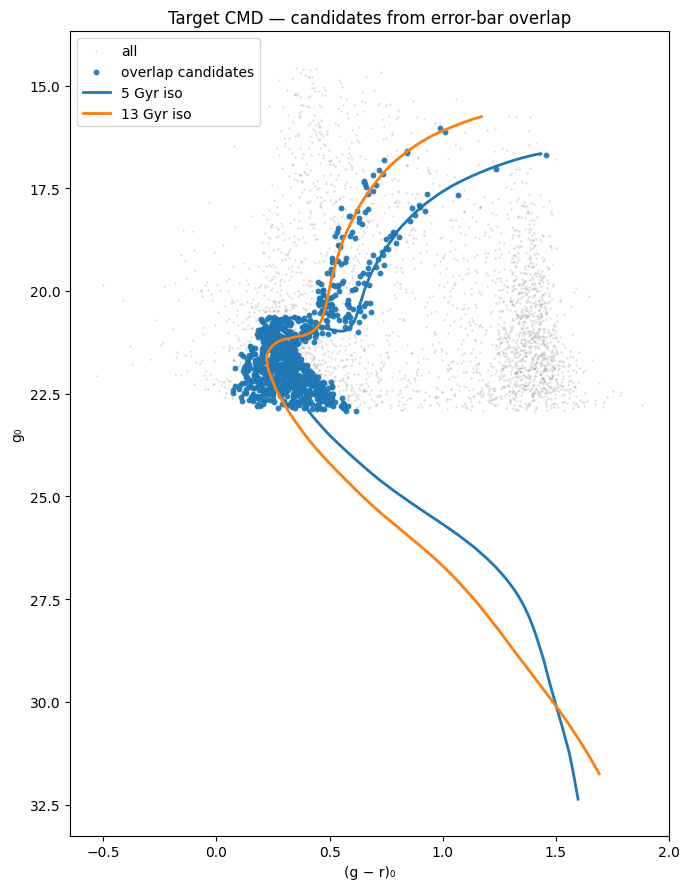

Target candidates: 880 out of 3206


In [2]:
# Cell 2 — Plot target CMD with overlap-selected candidates

df_t = field_map["target"]

plt.figure(figsize=(7,9))

# all stars
plt.scatter(df_t["g_r"], df_t["g0"], s=1, alpha=0.15, color="gray", label="all")

# candidates
plt.scatter(df_t.loc[df_t["cand_either_overlap"], "g_r"],
            df_t.loc[df_t["cand_either_overlap"], "g0"],
            s=10, alpha=0.9, label="overlap candidates")

# isochrones
plt.plot(c5_iso,  g5_iso,  lw=2, label="5 Gyr iso")
plt.plot(c13_iso, g13_iso, lw=2, label="13 Gyr iso")

plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("Target CMD — candidates from error-bar overlap")
plt.legend()
plt.tight_layout()
plt.show()

print("Target candidates:",
      df_t["cand_either_overlap"].sum(),
      "out of", len(df_t))

In [3]:
# --- pick fields to plot ---
field_map = {fid: df for fid, df in fields}
control_ids = [fid for fid in field_map.keys() if fid != "target"]
n_controls_to_plot = min(8, len(control_ids))
plot_ids = ["target"] + random.sample(control_ids, k=n_controls_to_plot)

# --- isochrones shifted to Sgr distance (for plotting only) ---
def iso_app_arrays(Mg_iso, Mr_iso, DM):
    g_app = Mg_iso + DM
    r_app = Mr_iso + DM
    c_app = g_app - r_app
    return c_app, g_app

c5_app, g5_app   = iso_app_arrays(Mg5,  Mr5,  DM_SGR)
c13_app, g13_app = iso_app_arrays(Mg13, Mr13, DM_SGR)

n = len(plot_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, fid in zip(axes, plot_ids):
    dfp = field_map[fid]

    # background
    ax.scatter(dfp["g_r"], dfp["g0"], s=1, alpha=0.07, color="gray", label="all")

    # MSTO shading
    ax.axvspan(msto["cmin"], msto["cmax"], alpha=0.06)
    ax.axhspan(msto["gmin"], msto["gmax"], alpha=0.06)

    # candidates (correct logic)
    ax.scatter(dfp.loc[dfp["cand_5only"], "g_r"], dfp.loc[dfp["cand_5only"], "g0"],
               s=10, alpha=0.85, label="5 only")
    ax.scatter(dfp.loc[dfp["cand_13only"], "g_r"], dfp.loc[dfp["cand_13only"], "g0"],
               s=10, alpha=0.85, label="13 only")
    ax.scatter(dfp.loc[dfp["cand_both"], "g_r"], dfp.loc[dfp["cand_both"], "g0"],
               s=12, alpha=0.95, label="both")

    # isochrones as points
    ax.scatter(c5_app,  g5_app,  s=5, alpha=0.35, label="iso 5Gyr")
    ax.scatter(c13_app, g13_app, s=5, alpha=0.35, label="iso 13Gyr")

    N = len(dfp)
    Nc = int(dfp["cand_either"].sum())
    Nm = int(dfp["in_msto"].sum())
    Ncm = int(dfp["cand_msto"].sum())
    ax.set_title(f"{fid}\nN={N}, cand={Nc}\nMSTO N={Nm}, cand={Ncm}")

    ax.invert_yaxis()
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(23.5, 13)

for k in range(len(plot_ids), len(axes)):
    axes[k].axis("off")

fig.text(0.5, 0.04, "(g − r)₀", ha="center", fontsize=12)
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc="upper right", fontsize=10)

fig.suptitle(
    f"Target + controls: DM-consistent candidates + Sgr isochrones\n"
    f"(DM={DM_SGR:.2f}, χ²<{CHI2_THRESH}, |DM_best−DM|<{DM_TOL}, MSTO shaded)",
    y=0.995, fontsize=14
)

plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.96])
plt.show()

NameError: name 'random' is not defined